In [57]:
# Task 1: Exploratory Data Analysis(EDA)

In [58]:
import pandas as pd
import numpy as np
df = pd.read_csv("Pharma_Industry.csv")   
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None


In [59]:
print(df.describe())

       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          0.971978   
min           -3.019512                       -3.773897         -2.940389   
25%           -0.642003                       -0.565168         -0.648157   
50%           -0.019340                        0.201532          0.027732   
75%            0.641151                        0.951375          0.710774   
max            2.949094                        4.111751          3.193108   

       Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
count                  500.000000                   500.000000       500.0000  
mean                     0.054398                    -0.171863         0.5200  
std                      0.986001                     0.983765    

In [60]:
print(df.isnull().sum())

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


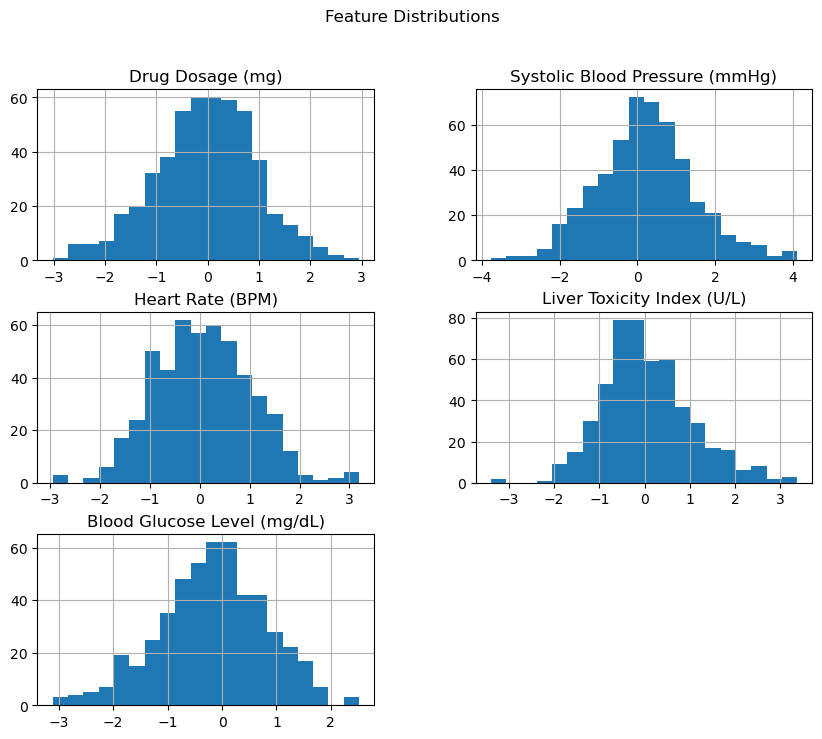

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_features = ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 
                    'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 
                    'Blood Glucose Level (mg/dL)']
df[numeric_features].hist(figsize=(10,8), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

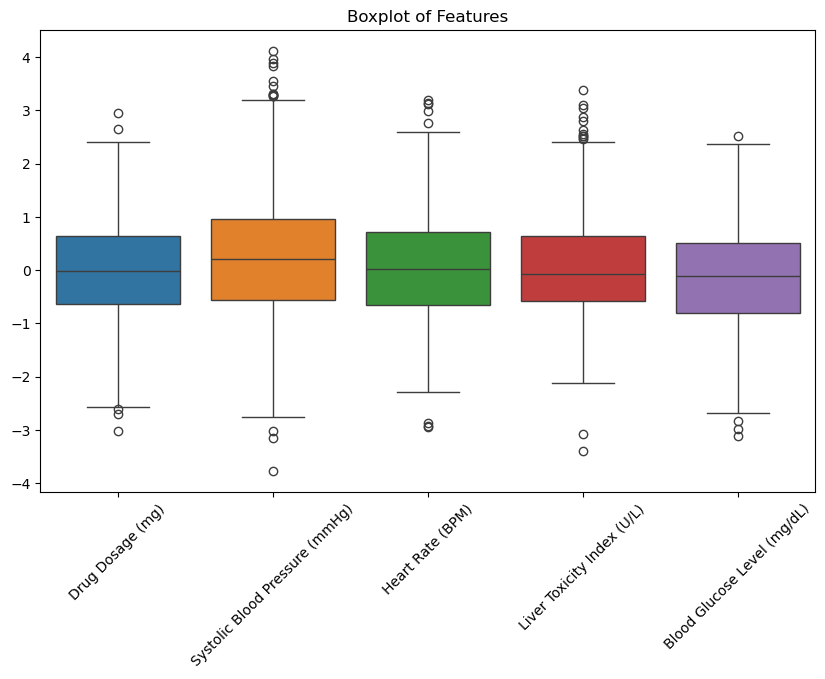

In [63]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[numeric_features])
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

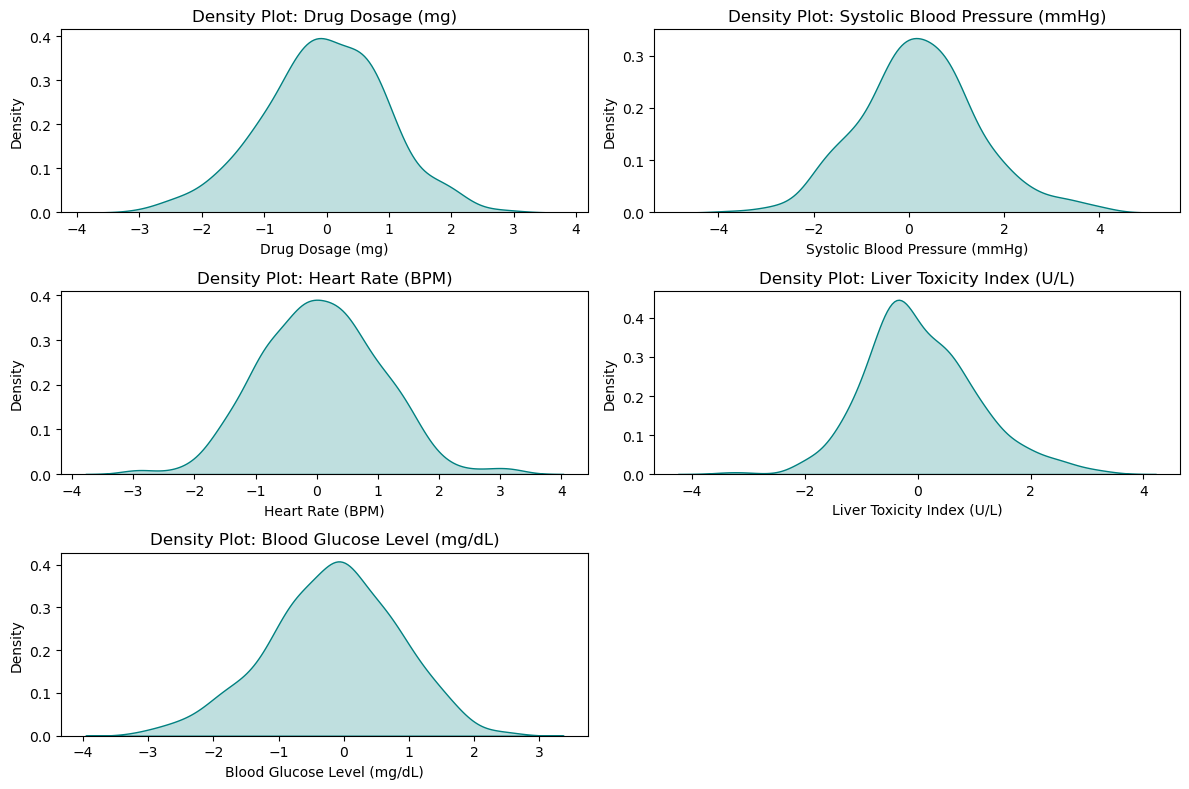

In [64]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(df[col], fill=True, color='teal')
    plt.title(f'Density Plot: {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [65]:
corr = df.corr()
print(corr)

                                Drug Dosage (mg)  \
Drug Dosage (mg)                        1.000000   
Systolic Blood Pressure (mmHg)          0.090618   
Heart Rate (BPM)                        0.040571   
Liver Toxicity Index (U/L)              0.128127   
Blood Glucose Level (mg/dL)             0.012434   
Drug Response                           0.043457   

                                Systolic Blood Pressure (mmHg)  \
Drug Dosage (mg)                                      0.090618   
Systolic Blood Pressure (mmHg)                        1.000000   
Heart Rate (BPM)                                     -0.039195   
Liver Toxicity Index (U/L)                            0.283672   
Blood Glucose Level (mg/dL)                           0.037228   
Drug Response                                         0.305226   

                                Heart Rate (BPM)  Liver Toxicity Index (U/L)  \
Drug Dosage (mg)                        0.040571                    0.128127   
Systolic Blo

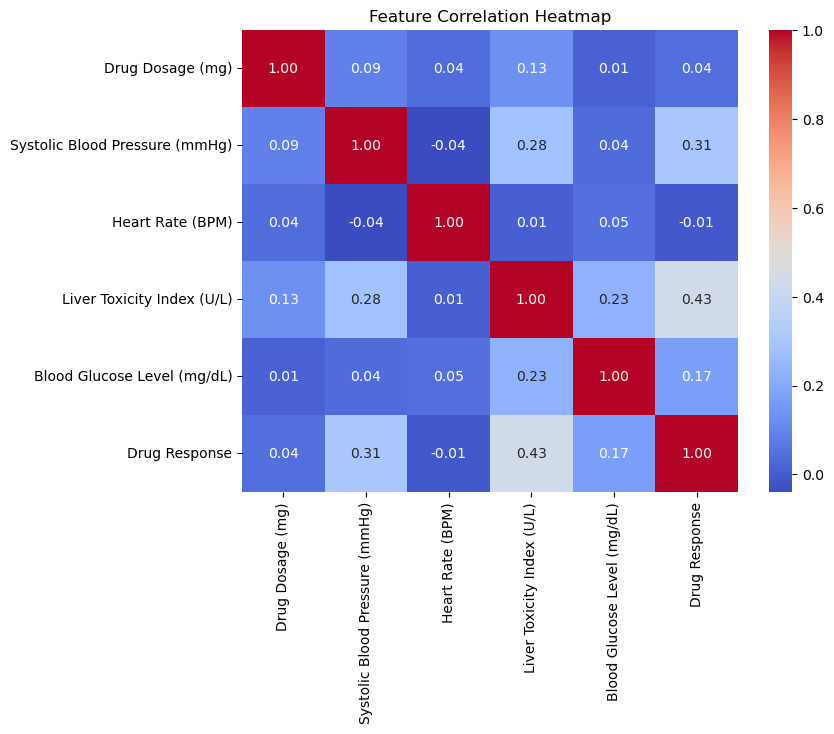

In [66]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [67]:
# Task 2 : Pre-Processing

In [68]:
print(df.dtypes)

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object


In [69]:
# No encoding required as there is no categorial column.

In [70]:
from sklearn.model_selection import train_test_split
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (400, 5)
Testing set size: (100, 5)


In [71]:
# Task 3 : Data Visualization

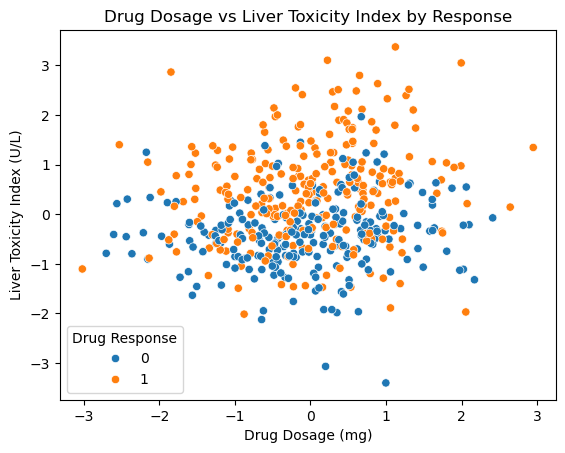

In [72]:
sns.scatterplot(data=df, x='Drug Dosage (mg)', y='Liver Toxicity Index (U/L)',hue='Drug Response')
plt.title("Drug Dosage vs Liver Toxicity Index by Response")
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Liver Toxicity Index (U/L)")
plt.show()
# Drug Dosage and Liver Toxicity Index do not show linear relationship. But they appear to be scaled as they are in range [-1,1].

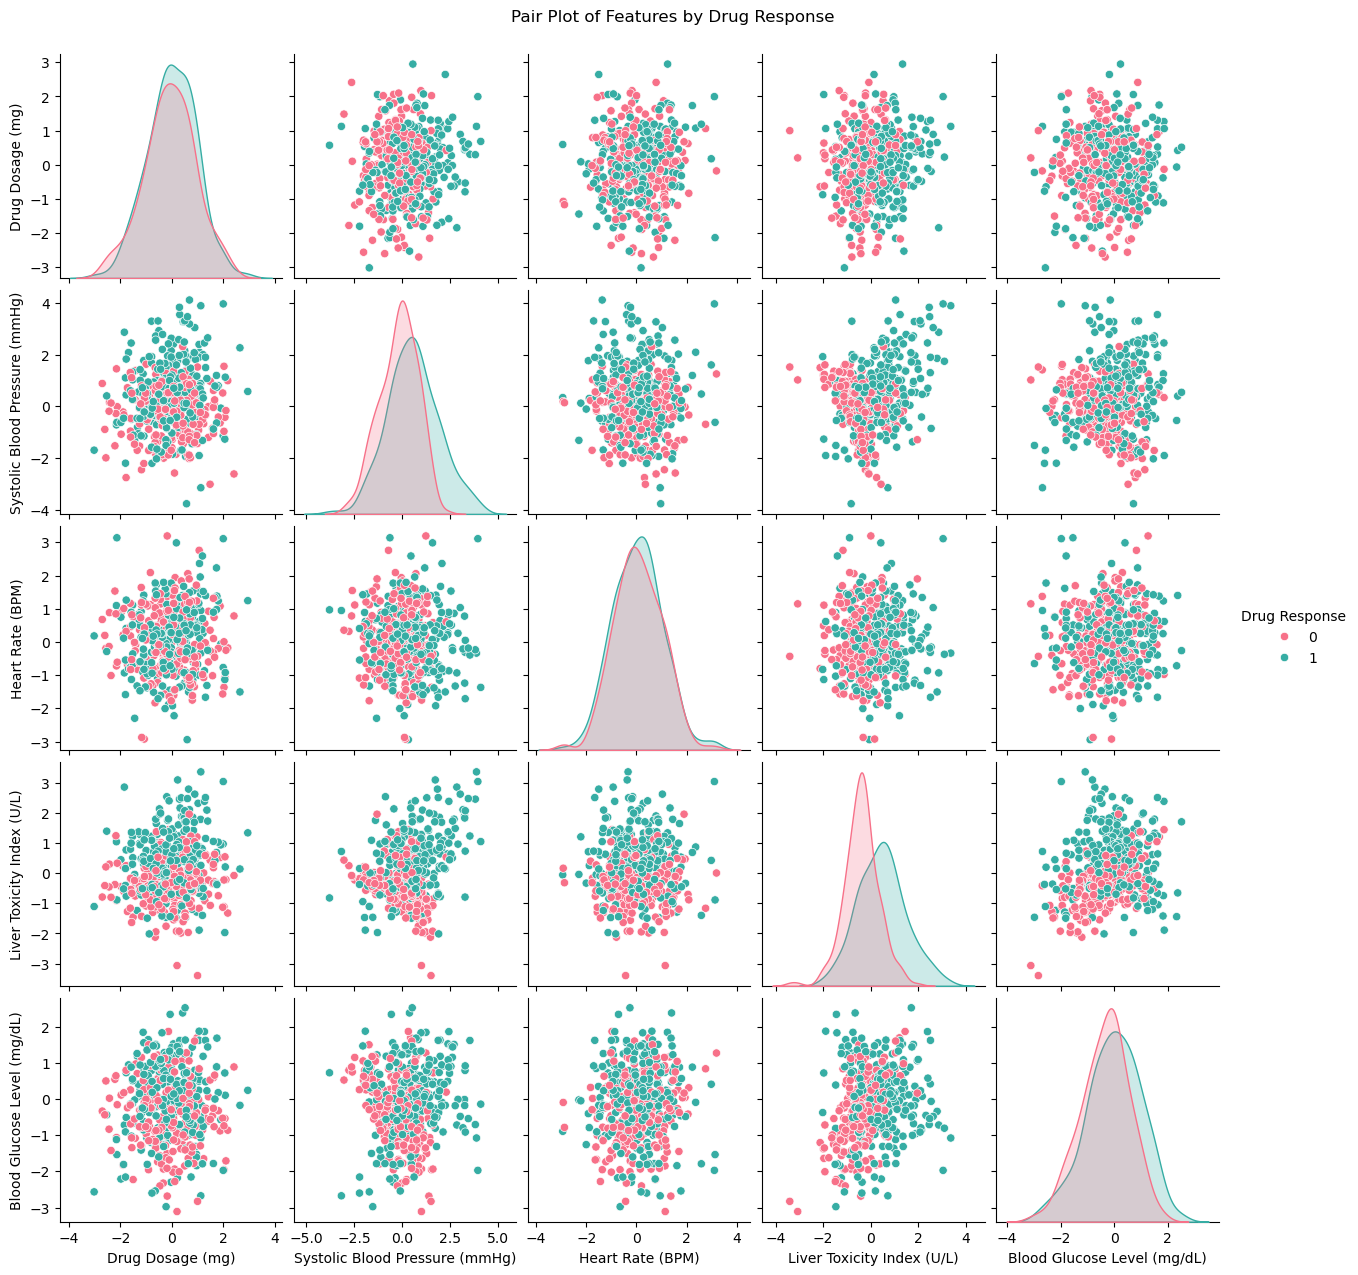

In [73]:
sns.pairplot(df, hue='Drug Response', diag_kind='kde', palette='husl')
plt.suptitle("Pair Plot of Features by Drug Response", y=1.02)
plt.show()
# Liver Toxicity is important feature to identify Drug Response as it shows variations.

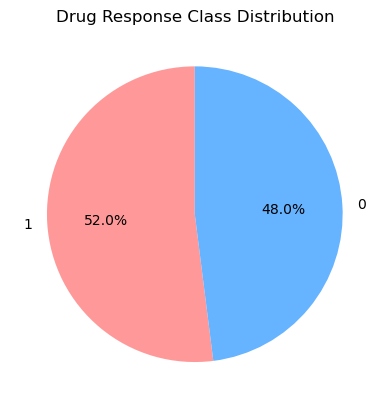

In [74]:
df['Drug Response'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title("Drug Response Class Distribution")
plt.ylabel("")
plt.show()

In [75]:
# The classes are fairly balanced hence the 4% od difference can be neglected.

In [76]:
# Task 4 : SVM Implementation

In [77]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [78]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(kernel='linear', random_state=42)

In [80]:
y_pred = svm_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("SVM Model Performance:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-Score : {f1:.3f}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# It is smiple way to use SVM which uses linear kernel. It shows 72% accuracy but slightly struggles with class 1 prediction.
# Moreover we have non-linear relationships in dataset hence it struggles to achieve high performance.

SVM Model Performance:
Accuracy : 0.720
Precision: 0.761
Recall   : 0.673
F1-Score : 0.714

Confusion Matrix:
 [[37 11]
 [17 35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



In [81]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

rbfacc = accuracy_score(y_test, y_pred_rbf)
rbfprec = precision_score(y_test, y_pred_rbf)
rbfrec = recall_score(y_test, y_pred_rbf)
rbff1 = f1_score(y_test, y_pred_rbf)

print("SVM RBF Model Performance:")
print(f"Accuracy : {rbfacc:.3f}")
print(f"Precision: {rbfprec:.3f}")
print(f"Recall   : {rbfrec:.3f}")
print(f"F1-Score : {rbff1:.3f}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("\nRBF Kernel Performance:")
print(classification_report(y_test, y_pred_rbf))
# It is complex type of SVM which uses rbf kernel(radial basis function). It shows 77% accuracy and predictes class 1 values more accurately.
# It also handles non-linear relationships more effectively than above SVM.

SVM RBF Model Performance:
Accuracy : 0.770
Precision: 0.754
Recall   : 0.827
F1-Score : 0.789

Confusion Matrix:
 [[34 14]
 [ 9 43]]

RBF Kernel Performance:
              precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



In [82]:
# Task 5 : Visualization of SVM Results

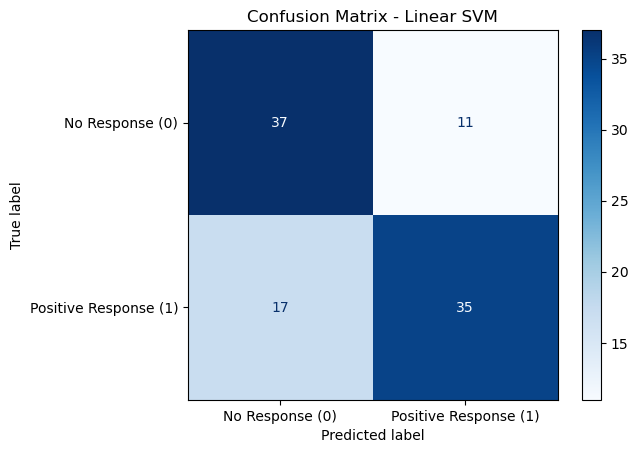

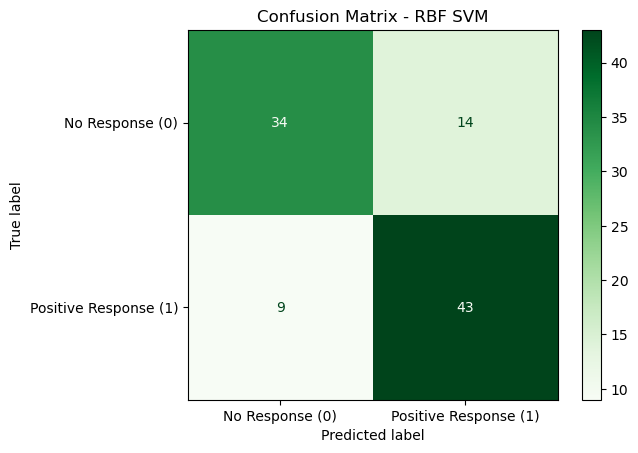

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Linear Kernel SVm
cm_linear = confusion_matrix(y_test, y_pred)
disp_linear = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=['No Response (0)', 'Positive Response (1)'])
disp_linear.plot(cmap='Blues')
plt.title("Confusion Matrix - Linear SVM")
plt.show()

# RBF Kernel SVM
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=['No Response (0)', 'Positive Response (1)'])
disp_rbf.plot(cmap='Greens')
plt.title("Confusion Matrix - RBF SVM")
plt.show()

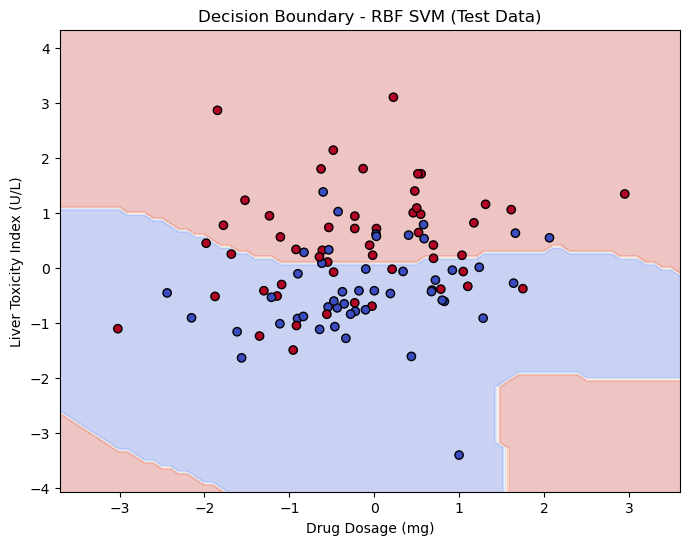

In [84]:
import numpy as np

X_train_2 = X_train[['Drug Dosage (mg)', 'Liver Toxicity Index (U/L)']]
X_test_2 = X_test[['Drug Dosage (mg)', 'Liver Toxicity Index (U/L)']]

svm_rbf_2 = SVC(kernel='rbf', gamma='scale')
svm_rbf_2.fit(X_train_2, y_train)

x_min, x_max = X_train_2.iloc[:, 0].min() - 1, X_train_2.iloc[:, 0].max() + 1
y_min, y_max = X_train_2.iloc[:, 1].min() - 1, X_train_2.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = svm_rbf_2.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X_train_2.columns))
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_test_2.iloc[:, 0], X_test_2.iloc[:, 1], c=y_test, edgecolor='k', cmap='coolwarm')
plt.title('Decision Boundary - RBF SVM (Test Data)')
plt.xlabel('Drug Dosage (mg)')
plt.ylabel('Liver Toxicity Index (U/L)')
plt.show()

In [85]:
# Approximately 20% of the red and blue test points lie outside their respective classification regions, 
# indicating some degree of misclassification. This suggests that while the model captures the general trend of separation, 
# there remains overlap between the classes that could be reduced with further feature engineering or hyperparameter tuning.

In [86]:
# Task 6 : Parameter Tuning and Optimization

In [108]:
from sklearn.model_selection import GridSearchCV
param_grid = {
'kernel': ['linear', 'rbf', 'poly'],
'C': [0.1,1],
'gamma': ['scale', 0.1, 0.01, 1]
}
svm_model_new = SVC()

grid_search = GridSearchCV(svm_model_new, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1], 'gamma': ['scale', 0.1, 0.01, 1],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [109]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.7525000000000001


In [110]:
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.77


In [111]:
#The parameter tuning process shows that moderate regularization (C=1) with the RBF kernel gives the best generalization performance. 
# This setting effectively captures the non-linear relationship between Drug Dosage and Liver Toxicity Index, while minimizing overfitting.

In [112]:
# Task 7: Comparison and Analysis

In [113]:
# 1] Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
# --> A) Linear :- Creates a straight-line (linear) decision boundary. Suitable for linearly separable data. It shows Test Accuracy of 0.72.
#                  The boundary was too simple to capture complex, non-linear patterns in the data.
# --> B) RBF :- Captures complex, non-linear relationships between features. It shows Test Accuracy of 0.77.
#               Provided the best accuracy and smooth, flexible decision boundaries.
# --> C) Polynomial :- Creates curved boundaries depending on the polynomial degree. It shows Test Accuracy of 0.74.
#                      Captured more variation but risked slight overfitting with higher degrees.

In [114]:
# 2] Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
# --> Strengths:
#        a) SVM effectively handled the non-linear patterns, especially with the RBF kernel, creating smooth and well-separated decision boundaries.
#        b) It performed well even on a small-to-medium dataset, showing robustness and good generalization (77% accuracy).
#        c) SVM is less affected by outliers due to the use of support vectors.
# --> Weakness:
#        a) Visualization showed that around 20% of test points (red and blue) lie outside their respective classification regions 
#          — indicating some overlap and misclassification.
#        b) SVM requires parameter tuning (C, gamma) to achieve good performance — default parameters gave lower accuracy.
#        c) SVM outputs are hard to interpret compared to simpler models like logistic regression.

In [116]:
# 3] Discuss practical implications of SVM in real-world classification tasks.
# --> In real-world applications, SVM is particularly useful when:
#          a) The relationship between predictors and output is non-linear.
#          b) The dataset is moderate in size with clearly separable patterns.
#          c) The goal is to achieve high accuracy and robust classification rather than model interpretability.
#          d) Eg:- i) Credit risk assessment – predicting whether a loan applicant will default or not.
#                  ii) Spam detection – classifying emails as spam or not spam.
#                  iii) Classifying tweets or reviews as positive, neutral, or negative.